In [1]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/checkpoint-20260502T194935Z-3-001.zip"

extract_to = "/content/drive/MyDrive/checkpoint"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Unzipped successfully!")
print(f"Extracted to: {extract_to}")

Unzipped successfully!
Extracted to: /content/drive/MyDrive/checkpoint


In [2]:
!pip install torchao --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.9 MB/s eta 0:00:00


In [3]:
import warnings
import logging
import os
warnings.filterwarnings("ignore")
from transformers import logging as hf_logging
hf_logging.set_verbosity_error()

from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

import torch
import torch.nn.functional as F
import numpy as np
from peft import PeftModel, PeftConfig
from transformers import AutoTokenizer, AutoModelForCausalLM

POS_COLOR  = "#27ae60"
NEG_COLOR  = "#e74c3c"
NEU_COLOR  = "#7f8c8d"
BG_COLOR   = "#f9f9f9"

label_names  = ["positive", "neutral", "negative"]
label_colors = [POS_COLOR, NEU_COLOR, NEG_COLOR]

adapter_path = "/content/drive/MyDrive/checkpoint/checkpoint"

config = PeftConfig.from_pretrained(adapter_path)

base_model = AutoModelForCausalLM.from_pretrained(
    config.base_model_name_or_path,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=HF_TOKEN
)

model = PeftModel.from_pretrained(base_model, adapter_path)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(
    adapter_path,
    token=HF_TOKEN
)

print(" Gemma loaded successfully!")


config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

 Gemma loaded successfully!


In [4]:
import torch
import torch.nn.functional as F

labels = [" positive", " neutral", " negative"]
label_token_ids = [tokenizer.encode(l, add_special_tokens=False)[0] for l in labels]
label_names = [l.strip() for l in labels]

def predict_sentiment(text):
    prompt = f"Classify the sentiment:\n{text}\nSentiment:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits[0, -1]

    scores = logits[label_token_ids]
    probs = F.softmax(scores, dim=0)

    result = {label_names[i]: round(probs[i].item(), 4) for i in range(len(labels))}
    predicted = max(result, key=result.get)

    print(f"\n Text: {text}")
    print(f"Predicted: {predicted.upper()}")
    print(f" Scores:")
    for label, score in result.items():
        bar = '█' * int(score * 30)
        print(f"   {label:10s} → {score:.4f} {bar}")

    return result

predict_sentiment("The company reported record profits this quarter, beating all analyst expectations.")
predict_sentiment("The firm filed for bankruptcy after failing to secure additional funding.")
predict_sentiment("The share subscription period will commence on 1 September and expire on 31 March.")


 Text: The company reported record profits this quarter, beating all analyst expectations.
Predicted: POSITIVE
 Scores:
   positive   → 0.9492 ████████████████████████████
   neutral    → 0.0503 █
   negative   → 0.0002 

 Text: The firm filed for bankruptcy after failing to secure additional funding.
Predicted: NEUTRAL
 Scores:
   positive   → 0.0010 
   neutral    → 0.9336 ████████████████████████████
   negative   → 0.0635 █

 Text: The share subscription period will commence on 1 September and expire on 31 March.
Predicted: NEUTRAL
 Scores:
   positive   → 0.0000 
   neutral    → 1.0000 ██████████████████████████████
   negative   → 0.0000 


{'positive': 0.0, 'neutral': 1.0, 'negative': 0.0}

In [5]:
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Load dataset
dataset = load_dataset("zeroshot/twitter-financial-news-sentiment")

print("Dataset structure:")
print(dataset)
print(f"\nValidation size: {len(dataset['validation'])} samples")
print(f"Train size:      {len(dataset['train'])} samples")
print(f"\nFeatures: {dataset['validation'].features}")

README.md: 0.00B [00:00, ?B/s]

sent_train.csv: 0.00B [00:00, ?B/s]

sent_valid.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/9543 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2388 [00:00<?, ? examples/s]

Dataset structure:
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})

Validation size: 2388 samples
Train size:      9543 samples

Features: {'text': Value('string'), 'label': Value('int64')}


In [8]:
# Twitter dataset label mapping
label_map = {0: "negative", 1: "positive", 2: "neutral"}

# Convert validation set to DataFrame
val_df = pd.DataFrame(dataset['validation'])
val_df['sentiment'] = val_df['label'].map(label_map)

print("\n✅ Validation set loaded!")
print(f"Shape: {val_df.shape}")
print(val_df.head())


✅ Validation set loaded!
Shape: (2388, 3)
                                                text  label sentiment
0  $ALLY - Ally Financial pulls outlook https://t...      0  negative
1  $DELL $HPE - Dell, HPE targets trimmed on comp...      0  negative
2  $PRTY - Moody's turns negative on Party City h...      0  negative
3                   $SAN: Deutsche Bank cuts to Hold      0  negative
4                  $SITC: Compass Point cuts to Sell      0  negative


In [9]:
print("\n" + "="*65)
print(" EXAMPLE STATEMENTS FROM VALIDATION SET")
print("="*65)

# Print 3 examples per class
for sentiment in ["positive", "negative", "neutral"]:
    print(f"\n{'─'*65}")
    print(f" {sentiment.upper()} EXAMPLES")
    print(f"{'─'*65}")

    examples = val_df[
        val_df['sentiment'] == sentiment
    ].head(3)

    for i, (_, row) in enumerate(examples.iterrows()):
        print(f"\n[{i+1}] {row['text']}")
        print(f"     Label: {row['sentiment'].upper()}")


 EXAMPLE STATEMENTS FROM VALIDATION SET

─────────────────────────────────────────────────────────────────
 POSITIVE EXAMPLES
─────────────────────────────────────────────────────────────────

[1] $ABEO as expected, keeps going higher. Cantor doubled its price target this morning to $4
     Label: POSITIVE

[2] $CACI - CACI gains a bull on growth acceleration https://t.co/VSXcxKpgly
     Label: POSITIVE

[3] $CNHI - CNH Industrial upped to Buy at Deutsche Bank on valuation https://t.co/w8VWmkTwAb
     Label: POSITIVE

─────────────────────────────────────────────────────────────────
 NEGATIVE EXAMPLES
─────────────────────────────────────────────────────────────────

[1] $ALLY - Ally Financial pulls outlook https://t.co/G9Zdi1boy5
     Label: NEGATIVE

[2] $DELL $HPE - Dell, HPE targets trimmed on compute headwinds https://t.co/YRUHZw7cYl
     Label: NEGATIVE

[3] $PRTY - Moody's turns negative on Party City https://t.co/MBD5TFGC4P
     Label: NEGATIVE

───────────────────────────────

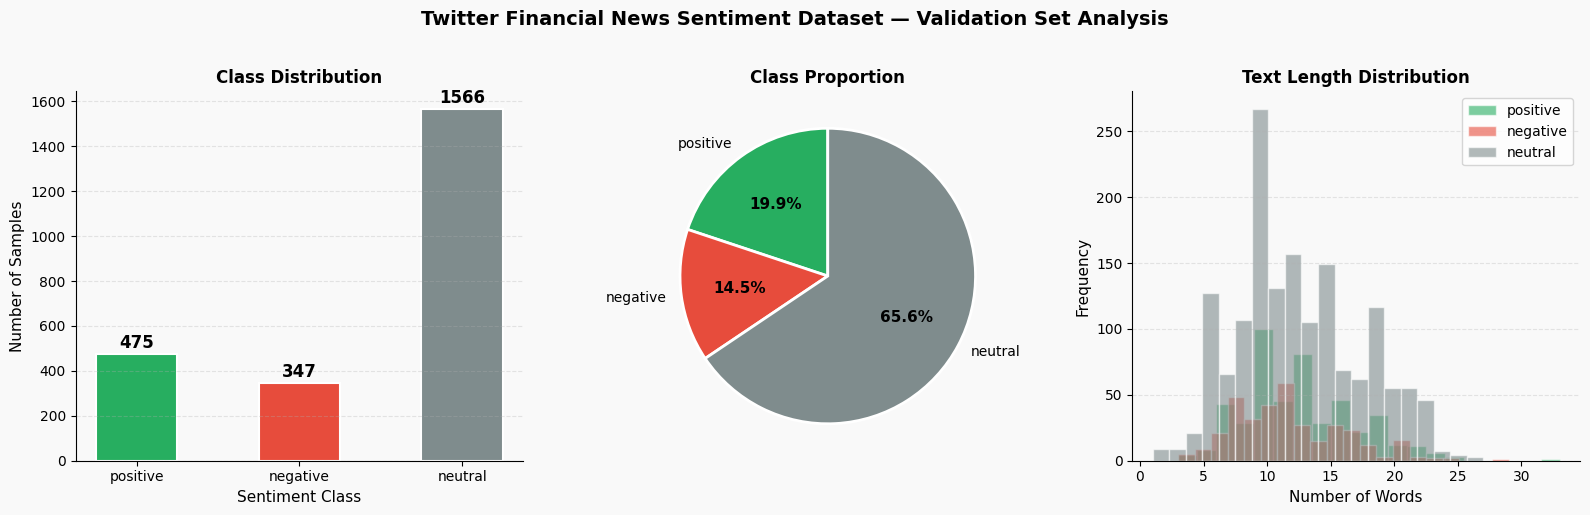

 Plot saved — twitter_dataset_analysis.png


In [10]:
POS_COLOR = "#27ae60"
NEG_COLOR = "#e74c3c"
NEU_COLOR = "#7f8c8d"
BG_COLOR  = "#f9f9f9"

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle(
    "Twitter Financial News Sentiment Dataset — Validation Set Analysis",
    fontsize=14, fontweight='bold', y=1.02
)

ax1 = axes[0]
ax1.set_facecolor(BG_COLOR)

class_counts = val_df['sentiment'].value_counts()
classes      = ['positive', 'negative', 'neutral']
counts       = [class_counts.get(c, 0) for c in classes]
colors       = [POS_COLOR, NEG_COLOR, NEU_COLOR]

bars = ax1.bar(
    classes, counts,
    color=colors,
    edgecolor='white',
    linewidth=1.5,
    width=0.5
)

for bar, count in zip(bars, counts):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 10,
        str(count),
        ha='center', va='bottom',
        fontweight='bold', fontsize=12
    )

ax1.set_title("Class Distribution", fontweight='bold', fontsize=12)
ax1.set_ylabel("Number of Samples", fontsize=11)
ax1.set_xlabel("Sentiment Class", fontsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

ax2 = axes[1]
ax2.set_facecolor(BG_COLOR)

wedges, texts, autotexts = ax2.pie(
    counts,
    labels=classes,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

ax2.set_title(
    "Class Proportion",
    fontweight='bold', fontsize=12
)

ax3 = axes[2]
ax3.set_facecolor(BG_COLOR)

val_df['text_length'] = val_df['text'].apply(
    lambda x: len(x.split())
)

for sentiment, color in zip(classes, colors):
    subset = val_df[val_df['sentiment'] == sentiment]['text_length']
    ax3.hist(
        subset,
        bins=20,
        alpha=0.6,
        color=color,
        label=sentiment,
        edgecolor='white'
    )

ax3.set_title(
    "Text Length Distribution",
    fontweight='bold', fontsize=12
)
ax3.set_xlabel("Number of Words", fontsize=11)
ax3.set_ylabel("Frequency", fontsize=11)
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(
    "twitter_dataset_analysis.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Plot saved — twitter_dataset_analysis.png")

In [11]:
print("\n" + "="*55)
print(" TWITTER VALIDATION SET STATISTICS")
print("="*55)

print(f"\n Total samples:     {len(val_df)}")
print(f" Total train:       {len(dataset['train'])}")

print(f"\n Class Distribution:")
for sentiment in classes:
    count = class_counts.get(sentiment, 0)
    pct   = count / len(val_df) * 100
    bar   = '█' * int(pct / 2)
    print(f"   {sentiment:<10} → {count:>4} ({pct:.1f}%) {bar}")

print(f"\n Text Length Stats (words):")
print(f"   Mean:   {val_df['text_length'].mean():.1f}")
print(f"   Median: {val_df['text_length'].median():.1f}")
print(f"   Min:    {val_df['text_length'].min()}")
print(f"   Max:    {val_df['text_length'].max()}")

print(f"\n Sample texts per class:")
for sentiment in classes:
    sample = val_df[
        val_df['sentiment'] == sentiment
    ]['text'].iloc[0]
    print(f"\n   [{sentiment.upper()}]")
    print(f"   {sample[:80]}...")


 TWITTER VALIDATION SET STATISTICS

 Total samples:     2388
 Total train:       9543

 Class Distribution:
   positive   →  475 (19.9%) █████████
   negative   →  347 (14.5%) ███████
   neutral    → 1566 (65.6%) ████████████████████████████████

 Text Length Stats (words):
   Mean:   12.3
   Median: 12.0
   Min:    1
   Max:    33

 Sample texts per class:

   [POSITIVE]
   $ABEO as expected, keeps going higher. Cantor doubled its price target this morn...

   [NEGATIVE]
   $ALLY - Ally Financial pulls outlook https://t.co/G9Zdi1boy5...

   [NEUTRAL]
   AM Best Revises Outlooks to Stable for Sublimity Insurance Company https://t.co/...


In [12]:
labels          = [" positive", " neutral", " negative"]
label_token_ids = [
    tokenizer.encode(l, add_special_tokens=False)[0]
    for l in labels
]

def get_probs(text):
    """Get probability distribution over 3 classes"""
    prompt = (
        f"You are a financial sentiment analysis expert. "
        f"Classify the sentiment of financial text as "
        f"positive, negative, or neutral.\n\n"
        f"Classify the sentiment of this financial text:\n\n"
        f"{text}\n\nSentiment:"
    )
    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        outputs = model(**inputs)
        logits  = outputs.logits[0, -1]

    scores = logits[label_token_ids]
    probs  = F.softmax(scores, dim=0).float().cpu().numpy()
    return probs

def predict_proba(texts):
    """Batch prediction for LIME/SHAP"""
    return np.array([get_probs(t) for t in texts])

def predict_label(text):
    """Get predicted label and confidence"""
    probs    = get_probs(text)
    pred_idx = np.argmax(probs)
    return label_names[pred_idx], probs[pred_idx], probs

test = "The company reported record profits this quarter."
label, conf, probs = predict_label(test)
print(f"Text:       {test}")
print(f"Prediction: {label.upper()}")
print(f"Confidence: {conf:.4f}")
print(f"All probs:  {dict(zip(label_names, probs.round(4)))}")

Text:       The company reported record profits this quarter.
Prediction: POSITIVE
Confidence: 1.0000
All probs:  {'positive': np.float32(1.0), 'neutral': np.float32(0.001), 'negative': np.float32(0.0)}


In [13]:
sentences = [
    "The company reported record profits this quarter, beating all analyst expectations.",
    "The bank filed for bankruptcy after failing to secure emergency funding.",
    "Profits rose significantly but the company cut its future outlook amid uncertainty."
]

In [14]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=ee23940e82d93b4056b3985b4c53495c17f814101ec2e606e86bb383b8da1f8d
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from lime.lime_text import LimeTextExplainer

explainer    = LimeTextExplainer(class_names=label_names)
WORDS_PER_ROW = 6

print(" LIME explainer ready!")

 LIME explainer ready!


In [17]:
sentence_idx = 0
sentence     = sentences[sentence_idx]

print(f"Computing LIME for: {sentence[:60]}...")

probs    = get_probs(sentence)
pred_idx = int(np.argmax(probs))
plabel   = label_names[pred_idx]
conf     = probs[pred_idx]

exp = explainer.explain_instance(
    sentence, predict_proba,
    num_features=15,
    num_samples=50,
    labels=[0, 1, 2],
    top_labels=None,
)

available    = list(exp.local_exp.keys())
use_label    = pred_idx if pred_idx in available else available[0]
word_weights = dict(exp.as_list(label=use_label))

print(f" Done! Predicted: {plabel.upper()} ({conf:.0%})")
print(f"Top words: {list(word_weights.items())[:5]}")

Computing LIME for: The company reported record profits this quarter, beating al...
 Done! Predicted: POSITIVE (100%)
Top words: [(np.str_('beating'), 0.11759380887985837), (np.str_('record'), 0.11518814906868023), (np.str_('reported'), 0.11172419204801791), (np.str_('all'), 0.09236377319574514), (np.str_('this'), 0.0645658554013003)]


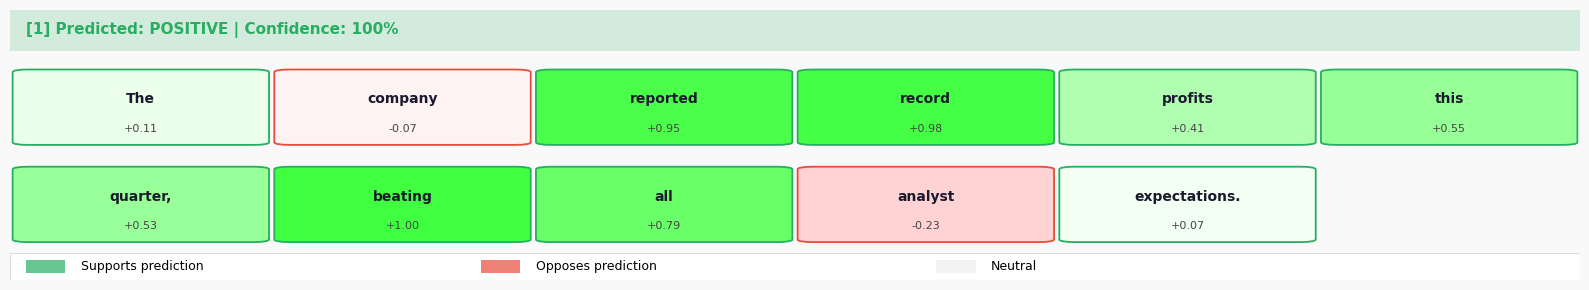

Saved — gemma_lime_s1.png


In [18]:
def plot_lime_sentence(sentence, word_weights, pred_idx,
                       plabel, conf, title_idx):

    words   = sentence.split()
    scores  = [
        word_weights.get(w, word_weights.get(w.strip('.,!?'), 0))
        for w in words
    ]
    max_abs = max(abs(s) for s in scores) or 1
    norm    = [s / max_abs for s in scores]

    fig, ax = plt.subplots(figsize=(16, 3))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor('#f8f9fa')
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Title strip
    ax.add_patch(plt.Rectangle(
        (0, 0.85), 1, 0.15,
        facecolor=label_colors[pred_idx],
        alpha=0.18, transform=ax.transAxes, zorder=0
    ))
    ax.text(
        0.01, 0.925,
        f"[{title_idx}] Predicted: {plabel.upper()} "
        f"| Confidence: {conf:.0%}",
        transform=ax.transAxes,
        fontsize=11, fontweight='bold',
        color=label_colors[pred_idx], va='center'
    )

    words_chunked = [
        words[i:i+WORDS_PER_ROW]
        for i in range(0, len(words), WORDS_PER_ROW)
    ]
    norms_chunked = [
        norm[i:i+WORDS_PER_ROW]
        for i in range(0, len(norm), WORDS_PER_ROW)
    ]

    n_rows    = len(words_chunked)
    tile_area = 0.72
    row_h     = tile_area / max(n_rows, 1)
    cell_w    = 1.0 / WORDS_PER_ROW

    for ri, (row_words, row_norms) in enumerate(
        zip(words_chunked, norms_chunked)
    ):
        y_center = 0.82 - (ri + 0.5) * row_h
        for ci, (word, n) in enumerate(zip(row_words, row_norms)):
            intensity = abs(n)
            if n > 0.05:
                fc = (1-intensity*0.75, 1, 1-intensity*0.75)
                ec = '#27ae60'
            elif n < -0.05:
                fc = (1, 1-intensity*0.75, 1-intensity*0.75)
                ec = '#e74c3c'
            else:
                fc = '#eeeeee'
                ec = '#aaaaaa'

            x_center = cell_w * ci + cell_w / 2
            ax.add_patch(mpatches.FancyBboxPatch(
                (x_center-cell_w*0.43, y_center-row_h*0.36),
                cell_w*0.86, row_h*0.72,
                boxstyle="round,pad=0.01",
                facecolor=fc, edgecolor=ec,
                linewidth=1.3,
                transform=ax.transAxes, zorder=2
            ))
            ax.text(
                x_center, y_center+row_h*0.08, word,
                transform=ax.transAxes,
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='#1a1a2e', zorder=3
            )
            ax.text(
                x_center, y_center-row_h*0.22,
                f"{n:+.2f}",
                transform=ax.transAxes,
                ha='center', va='center',
                fontsize=8, color='#444444', zorder=3
            )

    ax.add_patch(plt.Rectangle(
        (0, 0), 1, 0.10,
        facecolor='white', edgecolor='#dddddd',
        linewidth=0.8, transform=ax.transAxes, zorder=1
    ))
    for x, color, lbl in [
        (0.01, '#27ae60', "Supports prediction"),
        (0.30, '#e74c3c', "Opposes prediction"),
        (0.59, '#eeeeee', "Neutral")
    ]:
        ax.add_patch(plt.Rectangle(
            (x, 0.025), 0.025, 0.05,
            facecolor=color, alpha=0.7,
            transform=ax.transAxes, zorder=2
        ))
        ax.text(
            x+0.035, 0.05, lbl,
            transform=ax.transAxes,
            fontsize=9, va='center'
        )

    plt.tight_layout()
    fname = f"gemma_lime_s{title_idx}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved — {fname}")

plot_lime_sentence(
    sentence, word_weights,
    pred_idx, plabel, conf,
    title_idx=sentence_idx+1
)

Computing LIME for: The bank filed for bankruptcy after failing to secure emerge...


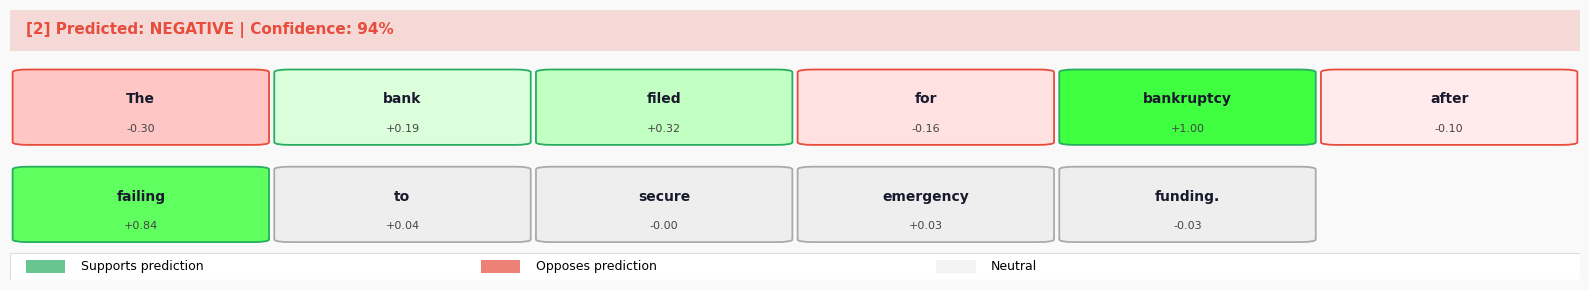

Saved — gemma_lime_s2.png


In [19]:
# Change to sentence 2
sentence_idx = 1
sentence     = sentences[sentence_idx]

print(f"Computing LIME for: {sentence[:60]}...")

probs    = get_probs(sentence)
pred_idx = int(np.argmax(probs))
plabel   = label_names[pred_idx]
conf     = probs[pred_idx]

exp = explainer.explain_instance(
    sentence, predict_proba,
    num_features=15,
    num_samples=50,
    labels=[0, 1, 2],
    top_labels=None,
)

available    = list(exp.local_exp.keys())
use_label    = pred_idx if pred_idx in available else available[0]
word_weights = dict(exp.as_list(label=use_label))

plot_lime_sentence(
    sentence, word_weights,
    pred_idx, plabel, conf,
    title_idx=sentence_idx+1
)

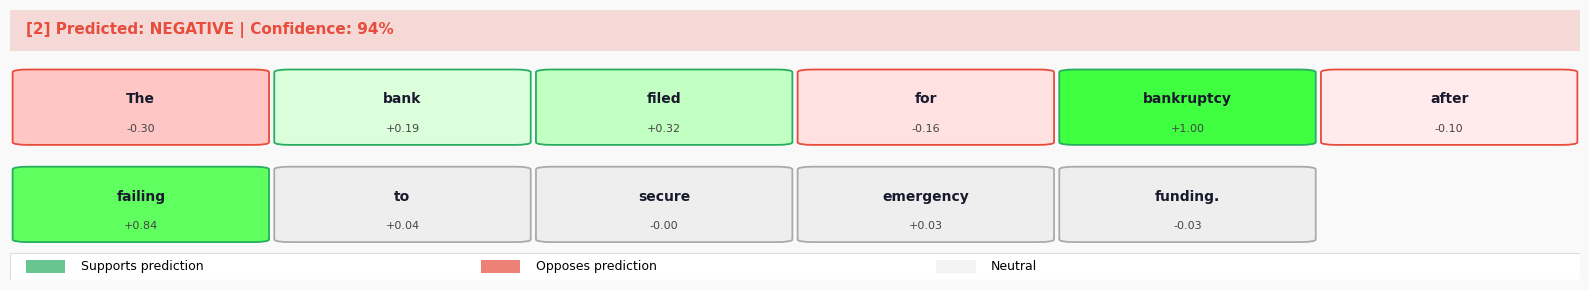

Saved — gemma_lime_s2.png


In [20]:
def plot_lime_sentence(sentence, word_weights, pred_idx,
                       plabel, conf, title_idx):

    words   = sentence.split()
    scores  = [
        word_weights.get(w, word_weights.get(w.strip('.,!?'), 0))
        for w in words
    ]
    max_abs = max(abs(s) for s in scores) or 1
    norm    = [s / max_abs for s in scores]

    fig, ax = plt.subplots(figsize=(16, 3))
    fig.patch.set_facecolor(BG_COLOR)
    ax.set_facecolor('#f8f9fa')
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Title strip
    ax.add_patch(plt.Rectangle(
        (0, 0.85), 1, 0.15,
        facecolor=label_colors[pred_idx],
        alpha=0.18, transform=ax.transAxes, zorder=0
    ))
    ax.text(
        0.01, 0.925,
        f"[{title_idx}] Predicted: {plabel.upper()} "
        f"| Confidence: {conf:.0%}",
        transform=ax.transAxes,
        fontsize=11, fontweight='bold',
        color=label_colors[pred_idx], va='center'
    )

    words_chunked = [
        words[i:i+WORDS_PER_ROW]
        for i in range(0, len(words), WORDS_PER_ROW)
    ]
    norms_chunked = [
        norm[i:i+WORDS_PER_ROW]
        for i in range(0, len(norm), WORDS_PER_ROW)
    ]

    n_rows    = len(words_chunked)
    tile_area = 0.72
    row_h     = tile_area / max(n_rows, 1)
    cell_w    = 1.0 / WORDS_PER_ROW

    for ri, (row_words, row_norms) in enumerate(
        zip(words_chunked, norms_chunked)
    ):
        y_center = 0.82 - (ri + 0.5) * row_h
        for ci, (word, n) in enumerate(zip(row_words, row_norms)):
            intensity = abs(n)
            if n > 0.05:
                fc = (1-intensity*0.75, 1, 1-intensity*0.75)
                ec = '#27ae60'
            elif n < -0.05:
                fc = (1, 1-intensity*0.75, 1-intensity*0.75)
                ec = '#e74c3c'
            else:
                fc = '#eeeeee'
                ec = '#aaaaaa'

            x_center = cell_w * ci + cell_w / 2
            ax.add_patch(mpatches.FancyBboxPatch(
                (x_center-cell_w*0.43, y_center-row_h*0.36),
                cell_w*0.86, row_h*0.72,
                boxstyle="round,pad=0.01",
                facecolor=fc, edgecolor=ec,
                linewidth=1.3,
                transform=ax.transAxes, zorder=2
            ))
            ax.text(
                x_center, y_center+row_h*0.08, word,
                transform=ax.transAxes,
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='#1a1a2e', zorder=3
            )
            ax.text(
                x_center, y_center-row_h*0.22,
                f"{n:+.2f}",
                transform=ax.transAxes,
                ha='center', va='center',
                fontsize=8, color='#444444', zorder=3
            )

    ax.add_patch(plt.Rectangle(
        (0, 0), 1, 0.10,
        facecolor='white', edgecolor='#dddddd',
        linewidth=0.8, transform=ax.transAxes, zorder=1
    ))
    for x, color, lbl in [
        (0.01, '#27ae60', "Supports prediction"),
        (0.30, '#e74c3c', "Opposes prediction"),
        (0.59, '#eeeeee', "Neutral")
    ]:
        ax.add_patch(plt.Rectangle(
            (x, 0.025), 0.025, 0.05,
            facecolor=color, alpha=0.7,
            transform=ax.transAxes, zorder=2
        ))
        ax.text(
            x+0.035, 0.05, lbl,
            transform=ax.transAxes,
            fontsize=9, va='center'
        )

    plt.tight_layout()
    fname = f"gemma_lime_s{title_idx}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved — {fname}")

plot_lime_sentence(
    sentence, word_weights,
    pred_idx, plabel, conf,
    title_idx=sentence_idx+1
)

Progressive word removal

In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

POS_COLOR  = "#27ae60"
NEG_COLOR  = "#e74c3c"
NEU_COLOR  = "#7f8c8d"
FLIP_COLOR = "#e67e22"
BG_COLOR   = "#f9f9f9"

label_names  = ["positive", "neutral", "negative"]
label_colors = [POS_COLOR, NEU_COLOR, NEG_COLOR]

sentence = "The company reported record profits this quarter, beating all analyst expectations."

print(f"Sentence: {sentence}")
print(f"Words: {len(sentence.split())}")

Sentence: The company reported record profits this quarter, beating all analyst expectations.
Words: 11


In [22]:

base_probs   = get_probs(sentence)
pred_idx     = int(np.argmax(base_probs))
plabel       = label_names[pred_idx]
base_conf    = base_probs[pred_idx]

print(f"Original prediction: {plabel.upper()}")
print(f"Confidence:          {base_conf:.4f}")
print(f"All probs:           {dict(zip(label_names, base_probs.round(4)))}")

Original prediction: POSITIVE
Confidence:          1.0000
All probs:           {'positive': np.float32(1.0), 'neutral': np.float32(1e-04), 'negative': np.float32(0.0)}


In [24]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=label_names)

print("Computing LIME word importance order...")

exp = explainer.explain_instance(
    sentence, predict_proba,
    num_features=20,
    num_samples=50,
    labels=[0, 1, 2],
    top_labels=None,
)

available    = list(exp.local_exp.keys())
use_label    = pred_idx if pred_idx in available else available[0]

word_order = [
    w for w, _ in sorted(
        exp.as_list(label=use_label),
        key=lambda x: abs(x[1]),
        reverse=True
    )
]

print(f"\n Word importance order:")
for i, w in enumerate(word_order[:8]):
    print(f"  {i+1}. '{w}'")

Computing LIME word importance order...

 Word importance order:
  1. 'beating'
  2. 'profits'
  3. 'company'
  4. 'record'
  5. 'all'
  6. 'The'
  7. 'this'
  8. 'reported'


In [25]:
steps        = ["Original"]
conf_history = [base_probs.copy()]
removed      = []
current_words = sentence.split()
flip_at      = None
flipped      = False

print("Removing words one by one...\n")

for word in word_order:
    curr_sentence = " ".join(current_words)
    words_lower   = [w.lower().strip('.,!?') for w in current_words]
    word_clean    = word.lower().strip('.,!?')

    if word_clean in words_lower:
        idx_to_remove = words_lower.index(word_clean)
        removed_word  = current_words.pop(idx_to_remove)
        removed.append(removed_word)

        if current_words:
            new_sentence = " ".join(current_words)
            new_probs    = get_probs(new_sentence)
        else:
            new_probs = np.array([1/3, 1/3, 1/3])

        new_pred = int(np.argmax(new_probs))
        steps.append(f"Remove\n'{removed_word}'")
        conf_history.append(new_probs.copy())

        # Check if flipped
        if new_pred != pred_idx and not flipped:
            flipped = True
            flip_at = len(removed)
            print(f" FLIP at removal #{flip_at}: '{removed_word}'")

        print(
            f"Step {len(removed):2d} | "
            f"Removed: '{removed_word:<15}' | "
            f"Pred: {label_names[new_pred]:<10} | "
            f"Conf: {new_probs[pred_idx]:.4f}"
        )

    if len(removed) >= 6:
        break

print(f"\n Done! Removed {len(removed)} words")
if flipped:
    print(f" Prediction flipped at removal #{flip_at}")
else:
    print(" Prediction stayed stable — robust model!")

Removing words one by one...

Step  1 | Removed: 'beating        ' | Pred: positive   | Conf: 1.0000
Step  2 | Removed: 'profits        ' | Pred: positive   | Conf: 1.0000
Step  3 | Removed: 'company        ' | Pred: positive   | Conf: 1.0000
 FLIP at removal #4: 'record'
Step  4 | Removed: 'record         ' | Pred: neutral    | Conf: 0.0001
Step  5 | Removed: 'all            ' | Pred: neutral    | Conf: 0.0000
Step  6 | Removed: 'The            ' | Pred: neutral    | Conf: 0.0510

 Done! Removed 6 words
 Prediction flipped at removal #4


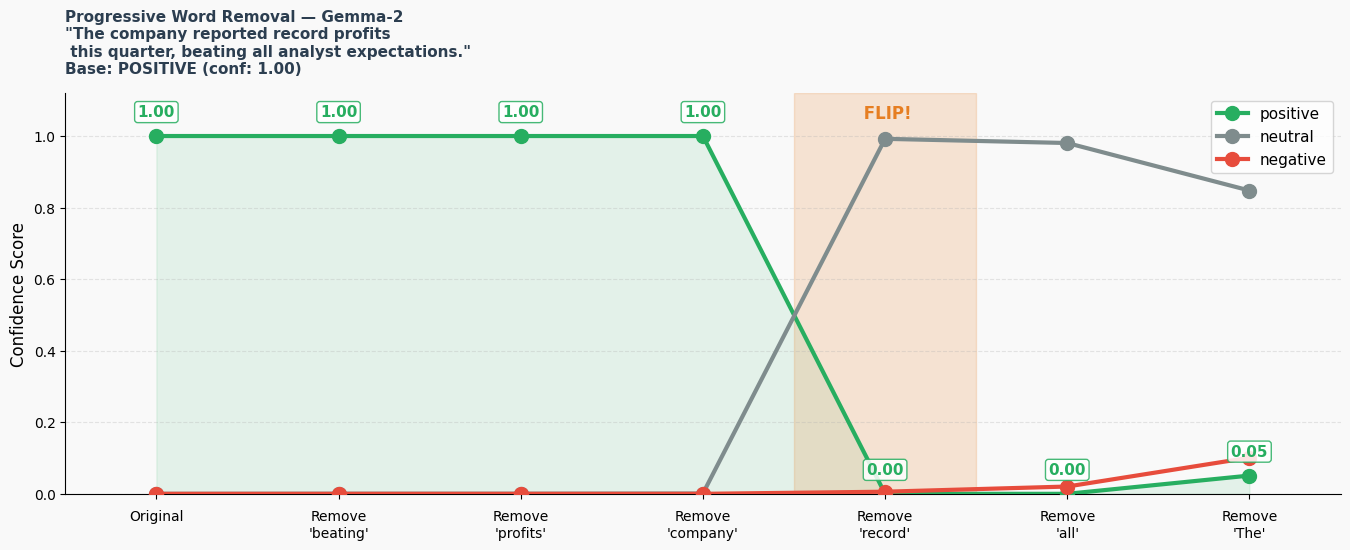

 Saved — gemma_progressive_removal.png


In [26]:
conf_arr = np.array(conf_history)
x        = np.arange(len(steps))

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(BG_COLOR)

# Plot confidence lines for each class
for ci, (lname, lcolor) in enumerate(
    zip(label_names, label_colors)
):
    ax.plot(
        x, conf_arr[:, ci],
        marker='o', label=lname,
        color=lcolor, linewidth=3,
        markersize=10, zorder=3
    )
    if ci == pred_idx:
        ax.fill_between(
            x, conf_arr[:, ci],
            alpha=0.10, color=lcolor
        )

# Annotate confidence values
for i, prob in enumerate(conf_arr[:, pred_idx]):
    ax.annotate(
        f"{prob:.2f}",
        xy=(i, prob),
        xytext=(0, 14),
        textcoords='offset points',
        ha='center', fontsize=11,
        color=label_colors[pred_idx],
        fontweight='bold',
        bbox=dict(
            boxstyle='round,pad=0.2',
            facecolor='white',
            edgecolor=label_colors[pred_idx],
            linewidth=1, alpha=0.85
        )
    )

# Mark flip point
if flipped and flip_at is not None:
    ax.axvspan(
        flip_at-0.5, flip_at+0.5,
        alpha=0.18, color=FLIP_COLOR, zorder=1
    )
    ax.text(
        flip_at, 1.05, ' FLIP!',
        ha='center', fontsize=12,
        color=FLIP_COLOR, fontweight='bold'
    )

# Labels
ax.set_xticks(x)
ax.set_xticklabels(steps, fontsize=10, ha='center')
ax.tick_params(axis='x', pad=8)
ax.set_ylabel("Confidence Score", fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_xlim(-0.5, len(steps)-0.5)

# Title
words_list = sentence.split()
mid        = len(words_list) // 2
line1      = " ".join(words_list[:mid])
line2      = " ".join(words_list[mid:])

ax.set_title(
    f"Progressive Word Removal — Gemma-2\n"
    f'"{line1}\n {line2}"\n'
    f"Base: {plabel.upper()} (conf: {base_conf:.2f})",
    fontsize=11, fontweight='bold',
    loc='left', pad=14, color='#2c3e50'
)

ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout(pad=2.5)
plt.savefig(
    "gemma_progressive_removal.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Saved — gemma_progressive_removal.png")

Applying explainability using SHAP

In [27]:
!pip install shap -q

import shap
print(" SHAP installed!")

 SHAP installed!


In [28]:

masker = shap.maskers.Text(tokenizer=r"\W+")

shap_explainer = shap.Explainer(
    predict_proba,
    masker,
    output_names=label_names
)

print("Computing SHAP values...")

shap_values = shap_explainer(
    [sentence],
    max_evals=200
)

print(" SHAP values computed!")

Computing SHAP values...


  0%|          | 0/110 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:21, 21.52s/it]               

 SHAP values computed!


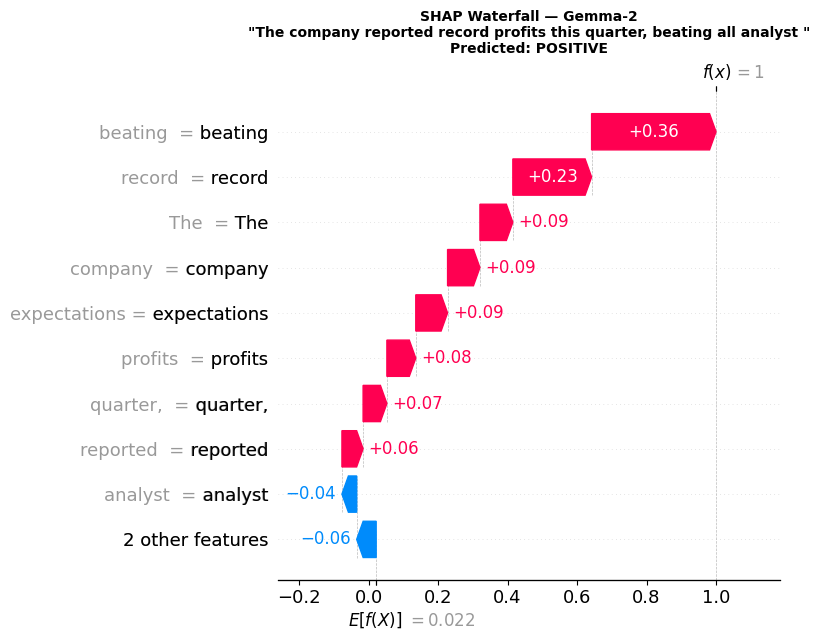

 Saved — gemma_shap_waterfall.png


In [29]:
plt.figure(figsize=(12, 5))

shap.plots.waterfall(
    shap_values[0, :, pred_idx],
    show=False
)

plt.title(
    f"SHAP Waterfall — Gemma-2\n"
    f'"{sentence[:70]}"\n'
    f"Predicted: {plabel.upper()}",
    fontweight='bold', fontsize=10
)

plt.tight_layout()
plt.savefig(
    "gemma_shap_waterfall.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Saved — gemma_shap_waterfall.png")

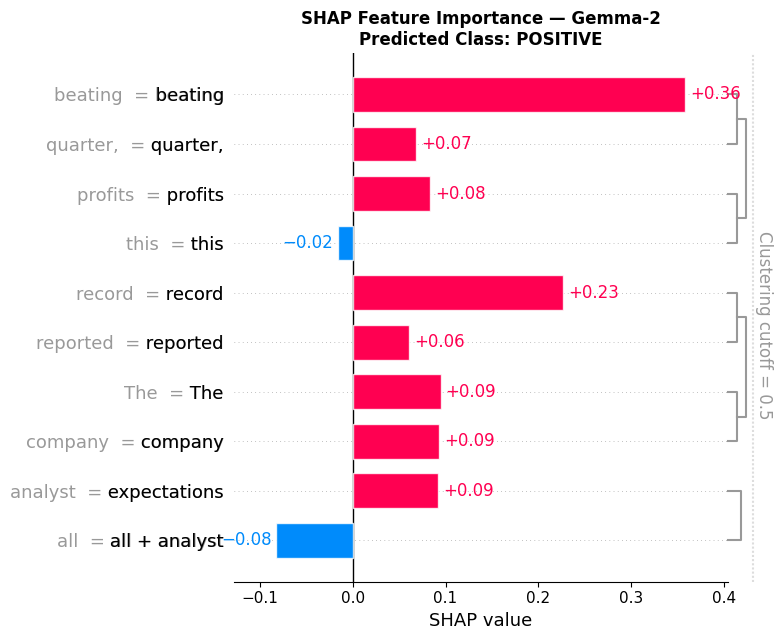

 Saved — gemma_shap_bar.png


In [30]:
plt.figure(figsize=(12, 4))

shap.plots.bar(
    shap_values[0, :, pred_idx],
    show=False
)

plt.title(
    f"SHAP Feature Importance — Gemma-2\n"
    f"Predicted Class: {plabel.upper()}",
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    "gemma_shap_bar.png",
    dpi=150, bbox_inches='tight'
)
plt.show()
print(" Saved — gemma_shap_bar.png")